# Imports

In [1]:
import torch
import numpy as np
import torch.nn as nn
from os.path import join
from datetime import datetime

from trajectory_utils.waypoint import WayPoint 
from trajectory_utils.plotter import plot_trajectory_data, set_publication_style
from trajectory_utils.data import traj_data_dict_get, save_traj_data, load_traj_data

set_publication_style()

# Reproducibility

In [2]:
def set_seed(seed=42):
    """
    Set random seeds for reproducibility.

    Ensures deterministic behavior across:
        - CPU operations
        - GPU operations

    Args:
        seed (int): random seed
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

# Phase Network

In [3]:
class PhaseNet(nn.Module):
    """
    Neural network for learning phase function τ(x).

    Maps spatial state x → scalar phase value,
    enforcing monotonic progression along trajectories.
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.LayerNorm(128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.net(x).squeeze(-1)

# Phase Learning (Ranking Loss)

In [4]:
def train_phase_network(TDList, epochs, lr=1e-3, num_pairs=512):
    """
    Train phase network using pairwise ranking loss.

    Enforces temporal ordering:
        τ(x_i) > τ(x_j) for i > j

    Uses sampled pairs for efficiency.

    Args:
        TDList: list of trajectory dicts
        epochs: training iterations
        lr: learning rate
        num_pairs: sampled pairs per trajectory

    Returns:
        trained phase model
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model = PhaseNet().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    
    margin = 0.1
    
    for epoch in range(epochs):
        total_loss = 0
        total_pairs = 0
        
        for TD in TDList:
            states = TD['states'][:, :3]
            T = len(states)
            
            if T < 2:
                continue
            
            states = torch.tensor(states, dtype=torch.float32).to(device)
            scores = model(states)
            
            # Sample pairs instead of full O(T²)
            i_idx = torch.randint(1, T, (num_pairs,), device=device)
            j_idx = torch.randint(0, T-1, (num_pairs,), device=device)
            j_idx = torch.minimum(j_idx, i_idx - 1)
            
            diff = scores[i_idx] - scores[j_idx]            
            loss = torch.log(1 + torch.exp(margin - diff)).mean()
            
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            total_loss += loss.item()
            total_pairs += num_pairs
        
        if epoch % 5 == 0:
            print(f"[Phase] Epoch {epoch:03d} | Loss: {total_loss:.6f} | Pairs: {total_pairs}")
    
    return model

# Phase Computation

In [5]:
def compute_tau(model, X):
    """
    Compute normalized phase values τ ∈ [0,1].

    Args:
        model: trained phase network
        X: (N,3) states

    Returns:
        tau: normalized phase values
    """
    device = next(model.parameters()).device
    
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    
    with torch.no_grad():
        scores = model(X_t).cpu().numpy()
    
    tau = (scores - scores.min()) / (scores.max() - scores.min() + 1e-6)
    
    return tau

# Dataset Construction

In [6]:
def build_pacer_dataset(TDList):
    """
    Construct PACER dataset from demonstrations.

    Extracts:
        - states X
        - actions A (velocities)
        - demo identifiers

    Returns:
        X: (N,3)
        A: (N,3)
        demo_ids: (N,)
    """
    X, A, demo_ids = [], [], []
    
    for i, TD in enumerate(TDList):
        states = TD['states'][:, :3]
        t_steps = TD['t_steps']
        
        diffs = np.diff(states, axis=0)
        dt = np.diff(t_steps)
        actions = diffs / dt[:, None]
        
        X.append(states[:-1])
        A.append(actions)
        demo_ids.append(np.full(len(actions), i))
    
    return np.vstack(X), np.vstack(A), np.concatenate(demo_ids)

# Robust Statistics & Improvements

In [7]:
def compute_loo_stats(A, bins, demo_ids, B):
    """
    Compute PACER robust statistics with leave-one-out (LOO) consensus.

    This implements the statistics described in Section 3.3–3.4 of the PACER paper:
    - Per-phase (bin) median action α_a[b]
    - Per-phase robust scale using MAD
    - Leave-one-out (LOO) versions α_a^{(-i)}[b], MAD^{(-i)}[b]

    These are used for:
        • Trust estimation via residuals
        • Pseudo-label debiasing (critical step)

    Args:
        A         : (N, d) array of actions
        bins      : (N,) integer bin assignment per sample (phase discretization)
        demo_ids  : (N,) integer demo index per sample
        B         : number of phase bins

    Returns:
        alpha_all : (B, d) global median action per bin
        MAD_all   : (B,)   global MAD scale per bin
        alpha_loo : (n_demos, B, d) LOO median per demo and bin
        MAD_loo   : (n_demos, B)    LOO MAD per demo and bin

    Notes:
        - MAD is scaled by 1.4826 for Gaussian consistency
        - LOO ensures a demo does NOT validate its own corrupted samples
        - Small epsilon added to avoid division instability
    """

    N, d = A.shape
    n_demos = int(demo_ids.max()) + 1

    # Initialize outputs
    alpha_all = np.zeros((B, d), dtype=np.float32)
    MAD_all = np.ones(B, dtype=np.float32)

    # 1. GLOBAL (non-LOO) statistics per bin
    for b in range(B):
        idx = np.where(bins == b)[0]

        if len(idx) == 0:
            # No samples in this bin → keep defaults
            continue

        A_bin = A[idx]

        # --- Median action α_a[b] ---
        med = np.median(A_bin, axis=0)
        alpha_all[b] = med

        # --- Residuals r = ||a - median|| ---
        r = np.linalg.norm(A_bin - med, axis=1)

        # --- Robust scale: MAD ---
        # MAD = 1.4826 * median(|r - median(r)|)
        med_r = np.median(r)
        mad = 1.4826 * np.median(np.abs(r - med_r))

        # Numerical stability (avoid zero scale)
        MAD_all[b] = mad if mad > 1e-6 else 1.0

    # 2. LEAVE-ONE-OUT (LOO) statistics
    alpha_loo = np.zeros((n_demos, B, d), dtype=np.float32)
    MAD_loo = np.ones((n_demos, B), dtype=np.float32)

    for i in range(n_demos):  # loop over demonstrations
        for b in range(B):    # loop over bins

            # Exclude current demo i
            idx = np.where((bins == b) & (demo_ids != i))[0]

            # If insufficient samples, fallback to global stats
            if len(idx) < 3:
                alpha_loo[i, b] = alpha_all[b]
                MAD_loo[i, b] = MAD_all[b]
                continue

            A_bin = A[idx]

            # --- LOO median α_a^{(-i)}[b] ---
            med = np.median(A_bin, axis=0)
            alpha_loo[i, b] = med

            # --- LOO MAD ---
            r = np.linalg.norm(A_bin - med, axis=1)
            med_r = np.median(r)
            mad = 1.4826 * np.median(np.abs(r - med_r))

            MAD_loo[i, b] = mad if mad > 1e-6 else 1.0

    return alpha_all, MAD_all, alpha_loo, MAD_loo

In [8]:
def compute_weights(A, bins, demo_ids, alpha_loo, MAD_loo, c=4.685, w_min=0.02):
    """
    Compute PACER per-sample trust weights using Tukey's biweight function.

    This implements Section 3.4 of the PACER paper:
        - Residual: r_{i,t} = ||a_{i,t} - α_a^{(-i)}[b]||
        - Normalization: z = r / MAD^{(-i)}[b]
        - Weighting: Tukey biweight (redescending M-estimator)

    Each sample is evaluated against a leave-one-out (LOO) consensus
    to prevent a demonstration from validating its own corrupted segments.

    Args:
        A         : (N, d) array of actions
        bins      : (N,) integer bin indices (phase discretization)
        demo_ids  : (N,) demo index per sample
        alpha_loo : (n_demos, B, d) LOO median actions
        MAD_loo   : (n_demos, B)    LOO MAD scales
        c         : Tukey cutoff (typically 4.685 for 95% efficiency)
        w_min     : minimum weight floor to avoid zero gradients

    Returns:
        weights   : (N,) array of per-sample trust weights in [w_min, 1]

    Notes:
        - z is a robust z-score using MAD (not standard deviation)
        - Tukey weighting:
            w = (1 - (z/c)^2)^2   if z ≤ c
            w = 0                 otherwise
        - Final weight is clipped to [w_min, 1]
    """

    N = len(A)
    weights = np.zeros(N, dtype=np.float32)

    for i in range(N):
        b = bins[i]            # phase bin
        d_id = demo_ids[i]     # demo index

        # --- LOO anchor and scale ---
        med = alpha_loo[d_id, b]   # α_a^{(-i)}[b]
        mad = MAD_loo[d_id, b]     # MAD^{(-i)}[b]

        # --- Residual: r = ||a - median|| ---
        r = np.linalg.norm(A[i] - med)

        # --- Robust z-score ---
        z = r / (mad + 1e-8)   # avoid division by zero

        # --- Tukey biweight ---
        if z <= c:
            w = (1.0 - (z / c) ** 2) ** 2
        else:
            w = 0.0

        # --- Apply minimum weight floor ---
        weights[i] = max(w, w_min)

    return weights

In [9]:
def compute_bin_stats_smooth(X, A, bins, B, smooth=5):
    """
    Compute PACER per-phase (bin) robust statistics and tangents.

    Implements Section 3.3 of the PACER paper:
        - Median action:      α_a[b]
        - Median state:       α_s[b]
        - Median magnitude:   β_a[b] = median(||a||)
        - Tangents:           t_a[b], t_s[b] via finite differences

    Additionally:
        - Handles empty bins via nearest-neighbor fill (required in practice)
        - Applies light smoothing across bins (implementation detail, not core method)

    Args:
        X      : (N, d_x) states
        A      : (N, d_a) actions
        bins   : (N,) integer bin indices
        B      : number of bins
        smooth : smoothing window size (>=1)

    Returns:
        alpha_a : (B, d_a) median action per bin
        beta_a  : (B,)     median action magnitude per bin
        alpha_s : (B, d_x) median state per bin
        t_a     : (B, d_a) unit action tangent per bin
        t_s     : (B, d_x) unit state tangent per bin

    Notes:
        - Tangents approximate local task dynamics
        - Smoothing helps reduce noise from sparse bins
        - Nearest-fill avoids invalid bins (important for stability)
    """

    d_a = A.shape[1]
    d_x = X.shape[1]

    alpha_a = np.zeros((B, d_a), dtype=np.float32)
    beta_a  = np.zeros(B, dtype=np.float32)
    alpha_s = np.zeros((B, d_x), dtype=np.float32)

    valid = np.zeros(B, dtype=bool)

    # 1. Compute per-bin medians
    for b in range(B):
        idx = np.where(bins == b)[0]

        if len(idx) == 0:
            continue

        A_bin = A[idx]
        X_bin = X[idx]

        # Median action α_a[b]
        alpha_a[b] = np.median(A_bin, axis=0)

        # Median magnitude β_a[b]
        beta_a[b] = np.median(np.linalg.norm(A_bin, axis=1))

        # Median state α_s[b]
        alpha_s[b] = np.median(X_bin, axis=0)

        valid[b] = True

    # 2. Nearest-neighbor fill for empty bins
    valid_idx = np.where(valid)[0]

    if len(valid_idx) == 0:
        raise ValueError("All bins are empty. Check phase computation.")

    for b in range(B):
        if not valid[b]:
            # Find closest valid bin
            nearest = valid_idx[np.argmin(np.abs(valid_idx - b))]

            alpha_a[b] = alpha_a[nearest]
            alpha_s[b] = alpha_s[nearest]
            beta_a[b]  = beta_a[nearest]

    # 3. Optional smoothing across bins (practical stabilization)
    def smooth_arr(arr):
        if smooth <= 1:
            return arr

        kernel = np.ones(smooth, dtype=np.float32) / float(smooth)

        # Apply convolution per dimension
        return np.stack([
            np.convolve(arr[:, i], kernel, mode='same')
            for i in range(arr.shape[1])
        ], axis=1)

    alpha_a = smooth_arr(alpha_a)
    alpha_s = smooth_arr(alpha_s)

    if smooth > 1:
        beta_a = np.convolve(beta_a, np.ones(smooth)/smooth, mode='same')

    # 4. Compute tangents (finite differences)
    t_a = np.gradient(alpha_a, axis=0)
    t_s = np.gradient(alpha_s, axis=0)

    # 5. Normalize tangents to unit vectors
    t_a /= (np.linalg.norm(t_a, axis=1, keepdims=True) + 1e-8)
    t_s /= (np.linalg.norm(t_s, axis=1, keepdims=True) + 1e-8)

    return alpha_a, beta_a, alpha_s, t_a, t_s

# Pseudo-Label Refinement

In [10]:
def build_pacer_targets(
    A, bins, demo_ids, weights, alpha_loo,
    beta_a, ta, ts,
    lambda_debias=0.5,
    rho0=0.5,
    eta0=0.5,
    kappa0=0.
):
    """
    Construct PACER pseudo-labels y* using phase-wise robust consensus.

    This implements Section 3.5 of the PACER paper:
        1. Debias toward LOO median
        2. Align with ribbon tangent
        3. Attenuate perpendicular deviations
        4. Adjust magnitude toward consensus speed
        5. Apply adaptive temporal smoothing (EMA)

    Args:
        A          : (N, d) original actions
        bins       : (N,) phase bin index per sample
        demo_ids   : (N,) demo index per sample
        weights    : (N,) trust weights w_{i,t}
        alpha_loo  : (n_demos, B, d) LOO median actions α_a^{(-i)}[b]
        beta_a     : (B,) median action magnitude per bin
        ta, ts     : (B, d) action/state tangents per bin

        lambda_debias : strength of debiasing toward α^{(-i)}
        rho0          : max sideways attenuation factor
        eta0          : max magnitude correction factor
        kappa0        : max EMA smoothing strength

    Returns:
        Y_star     : (N, d) refined pseudo-labels

    Notes:
        - Trust weights w ∈ [w_min, 1]
        - Low w ⇒ stronger correction toward consensus
        - High w ⇒ retain original action
    """

    N, d = A.shape
    Y_star = np.zeros_like(A, dtype=np.float32)

    # Track previous output for EMA
    prev = None
    prev_w = 1.0

    for i in range(N):
        b = bins[i]
        w = weights[i]
        d_id = demo_ids[i]

        # 1. Debias toward LOO anchor (Eq. in Sec 3.5)
        # y^(1) = γ a + (1-γ) α^{(-i)}
        gamma = 1.0 - lambda_debias * (1.0 - w)
        y1 = gamma * A[i] + (1.0 - gamma) * alpha_loo[d_id, b]

        # 2. Choose direction (state tangent preferred)
        # t_dir = t_s if available else t_a
        use_state = np.linalg.norm(ts[b]) > 1e-6
        tdir = ts[b] if use_state else ta[b]

        # Ensure unit direction (should already be normalized, but safe)
        tdir = tdir / (np.linalg.norm(tdir) + 1e-8)

        # Decompose action into parallel + perpendicular components
        y_par = np.dot(y1, tdir) * tdir
        y_perp = y1 - y_par

        # 3. Sideways attenuation (only if state geometry is valid)
        # y^(2) = y_parallel + (1 - ρ) y_perp
        # ρ = ρ0 (1 - w)
        rho = rho0 * (1.0 - w) if use_state else 0.0
        y2 = y_par + (1.0 - rho) * y_perp

        # 4. Magnitude (speed) correction
        # s = (1-η)||y|| + η β_a[b]
        cur_mag = np.linalg.norm(y2) + 1e-8
        target_mag = beta_a[b]

        eta = eta0 * (1.0 - w)
        new_mag = (1.0 - eta) * cur_mag + eta * target_mag

        y3 = (new_mag / cur_mag) * y2

        # 5. Adaptive EMA smoothing
        # y*_t = (1 - κ) y^(3) + κ y*_{t-1}
        # κ increases when both current and previous are low-trust
        if prev is None:
            Y_star[i] = y3
        else:
            kappa = kappa0 * (1.0 - w) * (1.0 - prev_w)
            Y_star[i] = (1.0 - kappa) * y3 + kappa * prev

        prev = Y_star[i]
        prev_w = w

    return Y_star

# Policy Network

In [11]:
class BCPolicy(nn.Module):
    """
    Feedforward policy mapping position → velocity.

    Learns a vector field:
        u = π(x)
    """
    def __init__(self):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 3)
        )
    
    def forward(self, x):
        return self.net(x)

# Training PACER Policy

In [12]:
def train_pacer(X, Y_star, weights, epochs, lr=1e-3):
    """
    Train policy on PACER-refined labels.

    Uses:
        - normalized inputs/outputs
        - weighted Huber loss

    Returns:
        model and normalization parameters
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0) + 1e-6
    X = (X - x_mean) / x_std

    y_mean = Y_star.mean(axis=0)
    y_std = Y_star.std(axis=0) + 1e-6
    Y_star = (Y_star - y_mean) / y_std

    X = torch.tensor(X, dtype=torch.float32).to(device)
    Y = torch.tensor(Y_star, dtype=torch.float32).to(device)
    W = torch.tensor(weights, dtype=torch.float32).to(device)

    model = BCPolicy().to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.SmoothL1Loss(reduction='none')

    for epoch in range(epochs):
        pred = model(X)

        loss = loss_fn(pred, Y).sum(dim=1)
        loss = (W * loss).mean()

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        if epoch % 20 == 0:
            print(f"Epoch {epoch}: Loss={loss.item():.6f}")

    return model, x_mean, x_std, y_mean, y_std

# Rollout Simulation

In [13]:
def rollout_policy_normalized(
    model, x0,
    x_mean, x_std,
    y_mean, y_std,
    phase_model=None,
    sim_duration=5.0,
    dt=1e-2
):
    """
    Roll out a trajectory using a learned policy with normalized inputs/outputs.

    The system follows first-order dynamics:
        x_{t+1} = x_t + u_t * dt,  where u_t = π(x_t)

    The policy operates in normalized space, so inputs and outputs are
    appropriately scaled before and after inference.

    Optionally, a phase model (PACER) can be used to compute τ(x) online.

    Args:
        model (nn.Module):
            Trained policy network mapping state → velocity.

        x0 (np.ndarray):
            Initial state (3,).

        x_mean, x_std:
            Normalization parameters for input state.

        y_mean, y_std:
            Normalization parameters for output velocity.

        phase_model (nn.Module, optional):
            Learned phase network. If provided, τ(x) is recorded.

        sim_duration (float):
            Total simulation time.

        dt (float):
            Integration timestep.

    Returns:
        TD (dict):
            Trajectory dictionary containing:
                - 'states': (N, 4) → [x, y, z, speed]
                - 't_steps': (N,)
                - 'progress': (N,) phase values (if phase_model provided)
    """
    model.eval()
    device = next(model.parameters()).device

    # Convert normalization parameters to tensors (avoid repeated conversions)
    x_mean_t = torch.tensor(x_mean, dtype=torch.float32, device=device)
    x_std_t  = torch.tensor(x_std,  dtype=torch.float32, device=device)
    y_mean_t = torch.tensor(y_mean, dtype=torch.float32, device=device)
    y_std_t  = torch.tensor(y_std,  dtype=torch.float32, device=device)

    if phase_model is not None:
        phase_model.eval()

    # Initialize state and logging variables
    x = torch.tensor(x0, dtype=torch.float32, device=device)
    last_pos = x.detach().cpu().numpy()

    TD = traj_data_dict_get()
    TD['progress'] = []

    count = 1
    t = 0.0

    for _ in range(int(sim_duration / dt)):

        # Normalize current state before passing to policy
        x_input = (x - x_mean_t) / x_std_t

        # Predict velocity and map back to original scale
        with torch.no_grad():
            u_norm = model(x_input.unsqueeze(0))
            u = u_norm.squeeze(0)
            u = u * y_std_t + y_mean_t

        # Integrate dynamics forward
        x = x + u * dt
        t += dt

        curr_pos = x.detach().cpu().numpy()
        curr_vel = np.linalg.norm((curr_pos - last_pos) / dt)
        last_pos = curr_pos.copy()

        # Compute phase value τ(x) if phase model is provided
        if phase_model is not None:
            with torch.no_grad():
                tau = phase_model(x.unsqueeze(0)).item()
        else:
            tau = 0.0

        # Store trajectory data (downsampled)
        if count % 5 == 0:
            TD['t_steps'].append(t)
            TD['states'].append(np.append(curr_pos, curr_vel))
            TD['progress'].append(tau)
            count = -1
        count += 1

    # Convert stored lists to numpy arrays
    TD['states'] = np.array(TD['states'])
    TD['t_steps'] = np.array(TD['t_steps'])
    TD['progress'] = np.array(TD['progress'])

    return TD

# Set FILEDATE

In [14]:
FILEDATE = 'J'

# Load Trajectory Data

In [15]:
TDList_Demo = np.array(load_traj_data(
    join("data_dummy", f"TDList_Demo_{FILEDATE}.pkl")
))

num_demos = len(TDList_Demo)

[INFO]: Trajectory Data loaded succesfully -> data_dummy\TDList_Demo_J.pkl


# Preprocess & Train

In [16]:
X, A, demo_ids = build_pacer_dataset(TDList_Demo)
phase_model = train_phase_network(TDList_Demo, epochs=250)
tau = compute_tau(phase_model, X)

[Phase] Epoch 000 | Loss: 5.758420 | Pairs: 4096
[Phase] Epoch 005 | Loss: 4.107924 | Pairs: 4096
[Phase] Epoch 010 | Loss: 3.708817 | Pairs: 4096
[Phase] Epoch 015 | Loss: 3.482880 | Pairs: 4096
[Phase] Epoch 020 | Loss: 3.408990 | Pairs: 4096
[Phase] Epoch 025 | Loss: 3.207563 | Pairs: 4096
[Phase] Epoch 030 | Loss: 3.104844 | Pairs: 4096
[Phase] Epoch 035 | Loss: 3.049761 | Pairs: 4096
[Phase] Epoch 040 | Loss: 2.809754 | Pairs: 4096
[Phase] Epoch 045 | Loss: 2.747387 | Pairs: 4096
[Phase] Epoch 050 | Loss: 2.635673 | Pairs: 4096
[Phase] Epoch 055 | Loss: 2.541221 | Pairs: 4096
[Phase] Epoch 060 | Loss: 2.310398 | Pairs: 4096
[Phase] Epoch 065 | Loss: 2.200175 | Pairs: 4096
[Phase] Epoch 070 | Loss: 2.124504 | Pairs: 4096
[Phase] Epoch 075 | Loss: 2.057530 | Pairs: 4096
[Phase] Epoch 080 | Loss: 2.238941 | Pairs: 4096
[Phase] Epoch 085 | Loss: 2.010543 | Pairs: 4096
[Phase] Epoch 090 | Loss: 1.951427 | Pairs: 4096
[Phase] Epoch 095 | Loss: 2.054466 | Pairs: 4096
[Phase] Epoch 100 | 

In [17]:
B = 96
bins = np.clip((tau * B).astype(int), 0, B-1)
alpha_a, beta_a, alpha_s, ta, ts = compute_bin_stats_smooth(X, A, bins, B)

In [18]:
alpha_all, MAD_all, alpha_loo, MAD_loo = compute_loo_stats(A, bins, demo_ids, B)

In [19]:
weights = compute_weights(A, bins, demo_ids, alpha_loo, MAD_loo)

In [20]:
Y_star = build_pacer_targets(A, bins, demo_ids, weights, alpha_loo, beta_a, ta, ts)

In [21]:
model, x_mean, x_std, y_mean, y_std = train_pacer(X, Y_star, weights, epochs=250)

Epoch 0: Loss=0.787443
Epoch 20: Loss=0.369955
Epoch 40: Loss=0.289337
Epoch 60: Loss=0.269046
Epoch 80: Loss=0.254943
Epoch 100: Loss=0.244845
Epoch 120: Loss=0.236596
Epoch 140: Loss=0.228577
Epoch 160: Loss=0.220232
Epoch 180: Loss=0.212149
Epoch 200: Loss=0.204648
Epoch 220: Loss=0.197984
Epoch 240: Loss=0.192670


# Load Original Waypoints 

### This is used for comparison!

In [22]:
WP_og = WayPoint( 
    path_to_waypts=join("data_dummy", f"WayPoints_{FILEDATE}.txt"),
    waypoint_density=1000.,
    smoothness_params = np.full(2, 5e-4),
    waypoints_width=5e-2
)

# Evaluation Block

In [23]:
"""
Rollout evaluation:
- simulate trajectory
- compute deviation from reference waypoints
"""

t_end = np.median([TD['t_steps'][-1] for TD in TDList_Demo])
x0 = np.median([TD['states'][0, :3] for TD in TDList_Demo], axis=0)

TDList_Learnt = []
num_exps = 5

for i in range(num_exps):
    x0_ = x0 + np.random.random(x0.shape) * 1e-2
    TD = rollout_policy_normalized(
        model, x0_, x_mean, x_std,
        y_mean, y_std, sim_duration=t_end,
        dt=5e-3
    )
    progress, nearest_pts = WP_og.find_progress_value(TD['states'][:, :2])
    index = np.argmin(np.abs(progress - 1))
    
    TD['name'] = 'PACER'
    TD['progress'] = progress[:index]
    TD['states'] = TD['states'][:index]
    TD['t_steps'] = TD['t_steps'][:index]
    TD['deviations'] = np.linalg.norm(TD['states'][:, :2] - nearest_pts[:index], axis=-1)
    TDList_Learnt.append(TD)

# Plot Trajectories

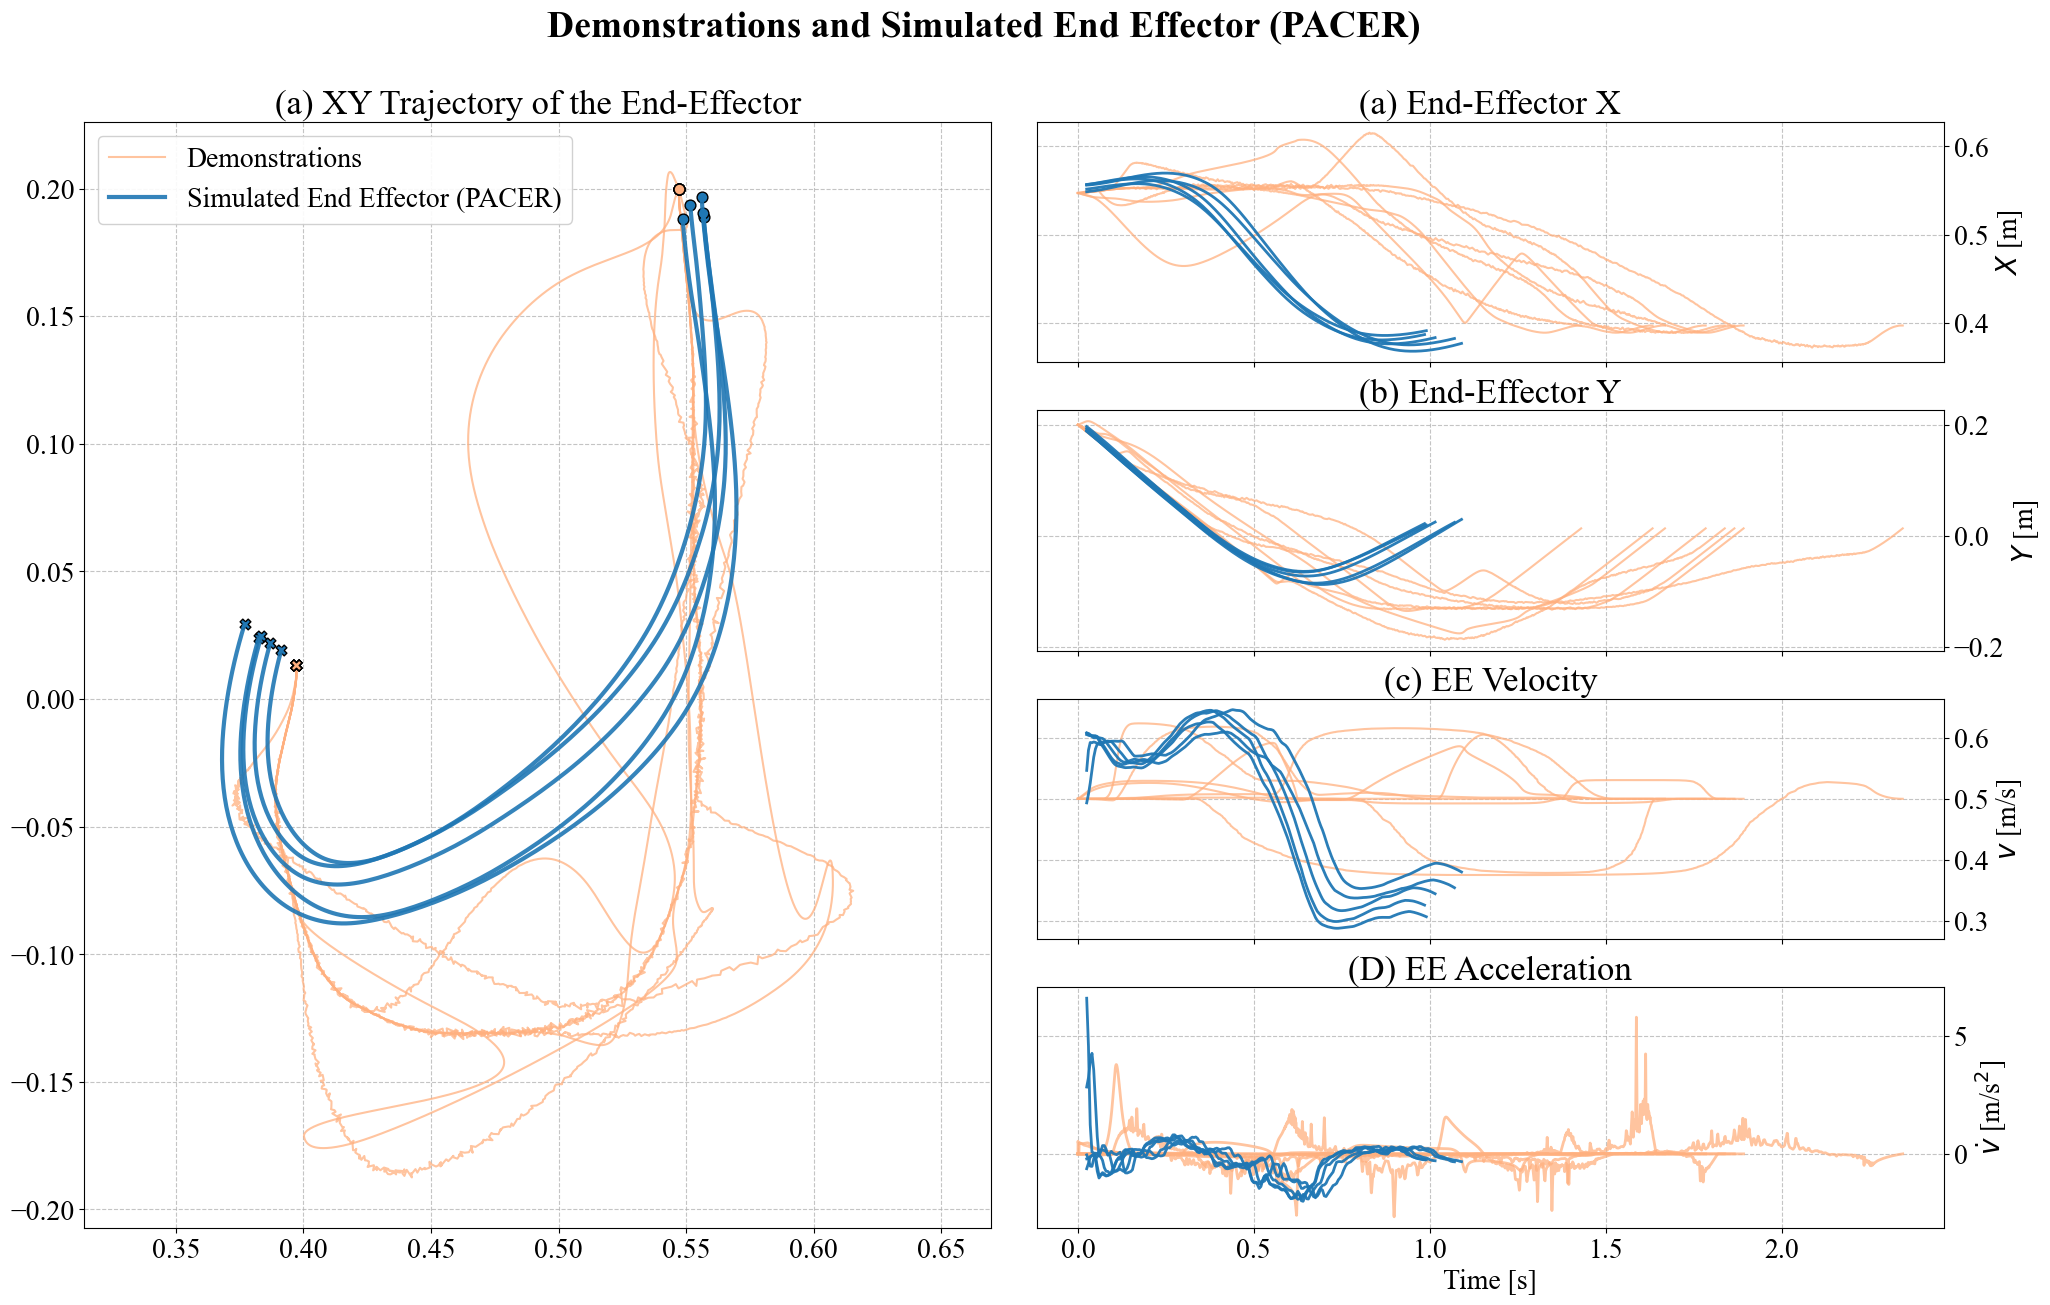

In [24]:
plot_trajectory_data(
    TDList_learnt=TDList_Learnt, 
    plot_state_dot_indices=[3],
    TDList_demo=TDList_Demo, 
    TD_demo_name="Demonstrations",
    TD_learnt_name="Simulated End Effector (PACER)", 
    filedate=f"{FILEDATE}_PACER"
)

# Save Trajectory Data

In [25]:
save_traj_data(
    TDList=TDList_Learnt, 
    filepath=join("data_dummy", f"TDList_Learnt_{FILEDATE}_PACER.pkl")
)

[INFO]: Trajectory Data saved succesfully -> data_dummy\TDList_Learnt_J_PACER.pkl
